# BitMEX 5m Data Gap & Validity Analysis

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow.dataset as ds

# Use the notebook-friendly version of tqdm
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# Set style for plots
plt.style.use('default')
sns.set_theme(style="whitegrid")

def analyze_data(data_dir: str):
    data_path = Path(data_dir)
    directories = [d for d in data_path.iterdir() if d.is_dir()]
    print(f"Found {len(directories)} symbols to analyze...")
    
    all_gaps = []
    symbol_stats = []
    expected_diff = pd.Timedelta(minutes=5)
    
    for symbol_dir in tqdm(directories, desc="Analyzing symbols"):
        symbol = symbol_dir.name
        
        try:
            dataset = ds.dataset(symbol_dir, format="parquet")
            df = dataset.to_table().to_pandas()
        except Exception as e:
            print(f"\nError loading data for {symbol}: {e}")
            continue
            
        if df.empty:
            continue
            
        df = df.sort_values('timestamp')
        total_rows = len(df)
        
        # --- 1. GAP ANALYSIS (Missing Time Ranges) ---
        df['time_gap'] = df['timestamp'].diff()
        time_gaps = df[df['time_gap'] > expected_diff]['time_gap']
        gaps_minutes = time_gaps.dt.total_seconds() / 60.0 if len(time_gaps) > 0 else pd.Series(dtype=float)
        
        # --- 2. INVALID LOGIC (Missing/Corrupt Prices) ---
        # Look for null prices (bid/ask/mid)
        null_prices = df[['mid_price', 'bid_price', 'ask_price']].isnull().any(axis=1).sum()
        
        # Count rows marked as formally invalid upstream in 'is_valid'
        invalid_flag = (~df['is_valid'].astype(bool)).sum() if 'is_valid' in df.columns else 0
        
        # Count exactly 0 prices (which usually imply broken feed)
        zero_prices = (df[['mid_price', 'bid_price', 'ask_price']] <= 0.0).any(axis=1).sum()
        
        total_corrupt = int(null_prices + invalid_flag + zero_prices)
        
        stats = {
            'symbol': symbol,
            'total_rows': total_rows,
            'gap_count': len(time_gaps),
            'gap_ratio_%': (len(time_gaps) / total_rows) * 100 if total_rows > 0 else 0,
            'max_gap_mins': gaps_minutes.max() if len(gaps_minutes) > 0 else 0,
            'mean_gap_mins': gaps_minutes.mean() if len(gaps_minutes) > 0 else 0,
            'p50_gap_mins': gaps_minutes.quantile(0.50) if len(gaps_minutes) > 0 else 0,
            'p99_gap_mins': gaps_minutes.quantile(0.99) if len(gaps_minutes) > 0 else 0,
            'null_prices': int(null_prices),
            'is_valid_false': int(invalid_flag),
            'zero_prices': int(zero_prices),
            'total_corrupt_rows': total_corrupt,
            'corrupt_ratio_%': (total_corrupt / total_rows) * 100 if total_rows > 0 else 0
        }
        symbol_stats.append(stats)
        
        if len(gaps_minutes) > 0:
            all_gaps.append(gaps_minutes)

    if not symbol_stats:
        print("\nNo data found across any sequence!")
        return None, None
        
    stats_df = pd.DataFrame(symbol_stats)
    all_gaps_series = pd.concat(all_gaps, ignore_index=True) if all_gaps else pd.Series(dtype=float)
    
    return stats_df, all_gaps_series


### Process Data

In [6]:
directory = r"d:\MASTER THESIS DATA\bitmex\processed_5m_bidask"
stats_df, all_gaps_series = analyze_data(directory)


Found 243 symbols to analyze...


Analyzing symbols:   0%|          | 0/243 [00:00<?, ?it/s]

### Display Top Invalid / NaN Rows

In [7]:
if stats_df is not None:
    print("\n" + "=" * 60)
    print("OVERALL INVALID ROW STATISTICS (Across all symbols)")
    print("=" * 60)
    print(f"Total Rows across universe: {stats_df['total_rows'].sum():,}")
    print(f"Total NaN Prices: {stats_df['null_prices'].sum():,}")
    print(f"Total Zero Prices: {stats_df['zero_prices'].sum():,}")
    print(f"Total Explicit 'is_valid=False' Rows: {stats_df['is_valid_false'].sum():,}")
    
    print("\n" + "=" * 60)
    print("TOP 10 SYMBOLS WITH MOST CORRUPT (NaN/Zero/Invalid) ROWS")
    print("=" * 60)
    worst_corrupt = stats_df.sort_values('corrupt_ratio_%', ascending=False).head(10)
    display(worst_corrupt[['symbol', 'corrupt_ratio_%', 'total_corrupt_rows', 'null_prices', 'zero_prices', 'is_valid_false']])



OVERALL INVALID ROW STATISTICS (Across all symbols)
Total Rows across universe: 27,683,455
Total NaN Prices: 5,744
Total Zero Prices: 0
Total Explicit 'is_valid=False' Rows: 5,744

TOP 10 SYMBOLS WITH MOST CORRUPT (NaN/Zero/Invalid) ROWS


,symbol,corrupt_ratio_%,total_corrupt_rows,null_prices,zero_prices,is_valid_false
211,USDTUSDC,4.798521,4050,2025,0,2025
30,AXLUSDT,3.876995,1494,747,0,747
234,XPLUSDT,2.741703,38,19,0,19
232,XMRUSDT,2.419355,12,6,0,6
239,ZECUSDT,1.992032,10,5,0,5
4,1TAIDOGEUSDT,1.983219,52,26,0,26
53,CATUSDT,1.131674,1138,569,0,569
210,UNIUSDT,0.695693,418,209,0,209
26,AUSD,0.637543,176,88,0,88
17,APEUSDT,0.348705,1034,517,0,517


### Corrupted Data Visualization

C:\Users\kacpe\AppData\Local\Temp\ipykernel_26496\2869163716.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_corrupt, x='corrupt_ratio_%', y='symbol', ax=ax1, palette='Reds_r')


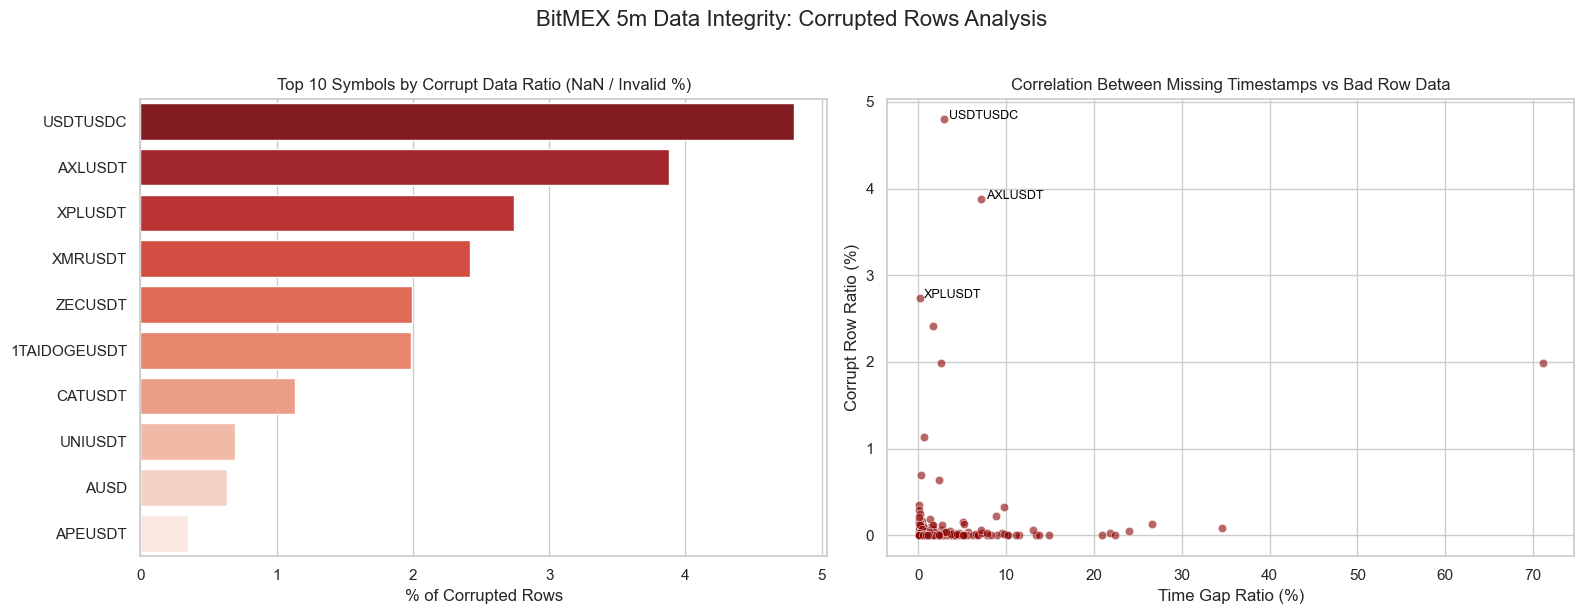

In [8]:
if stats_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('BitMEX 5m Data Integrity: Corrupted Rows Analysis', fontsize=16, y=1.02)
    
    # --- Plot 1: Top 10 Symbols by Broken Row Ratio ---
    ax1 = axes[0]
    worst_corrupt = stats_df.sort_values('corrupt_ratio_%', ascending=False).head(10)
    sns.barplot(data=worst_corrupt, x='corrupt_ratio_%', y='symbol', ax=ax1, palette='Reds_r')
    ax1.set_title('Top 10 Symbols by Corrupt Data Ratio (NaN / Invalid %)')
    ax1.set_xlabel('% of Corrupted Rows')
    ax1.set_ylabel('')
    
    # --- Plot 2: Scatterplot of Gaps VS Corrupt Rows ---
    ax2 = axes[1]
    sns.scatterplot(data=stats_df, x='gap_ratio_%', y='corrupt_ratio_%', alpha=0.6, color='darkred', ax=ax2)
    ax2.set_title('Correlation Between Missing Timestamps vs Bad Row Data')
    ax2.set_xlabel('Time Gap Ratio (%)')
    ax2.set_ylabel('Corrupt Row Ratio (%)')
    
    # Annotate top extreme outliers in scatterplot
    for i, row in stats_df.sort_values('corrupt_ratio_%', ascending=False).head(3).iterrows():
        ax2.text(row['gap_ratio_%'] + 0.5, row['corrupt_ratio_%'], row['symbol'], fontsize=9, color='black', ha='left')
        
    plt.tight_layout()
    plt.show()


### Gap Visualizations (Original Timeline Holes)

C:\Users\kacpe\AppData\Local\Temp\ipykernel_26496\3315729748.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_freq, x='gap_ratio_%', y='symbol', ax=ax2, palette='Oranges_r')
C:\Users\kacpe\AppData\Local\Temp\ipykernel_26496\3315729748.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_max, x='max_gap_mins', y='symbol', ax=ax3, palette='Purples_r')
C:\Users\kacpe\AppData\Local\Temp\ipykernel_26496\3315729748.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_median, x='p50_gap_mins', y='symbol', ax=ax4

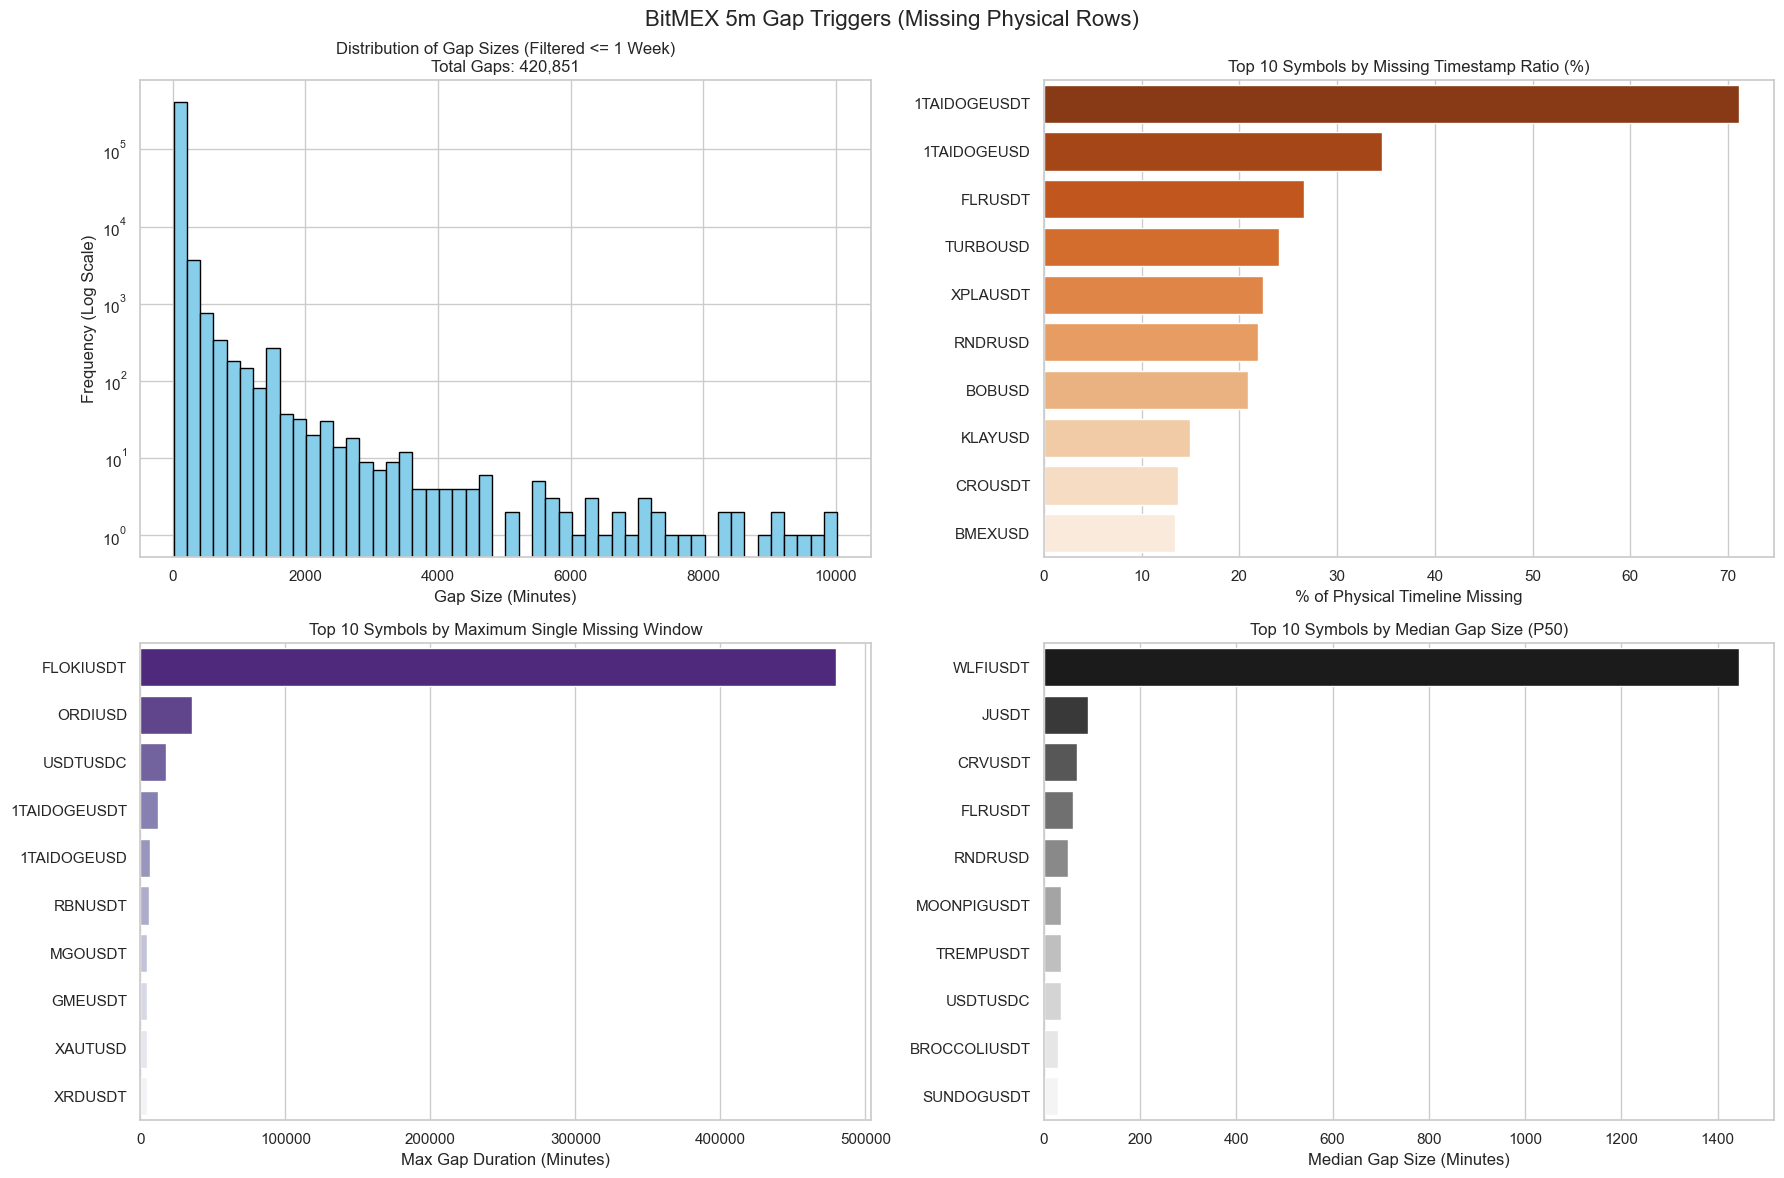

In [9]:
if stats_df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('BitMEX 5m Gap Triggers (Missing Physical Rows)', fontsize=16, y=0.98)
    
    # --- Plot 1: Histogram of all gaps (Log Scale) ---
    max_mins_plot = 7 * 24 * 60 
    gaps_filtered = all_gaps_series[all_gaps_series <= max_mins_plot]
    
    ax1 = axes[0, 0]
    ax1.hist(gaps_filtered, bins=50, color='skyblue', edgecolor='black', log=True)
    ax1.set_title(f'Distribution of Gap Sizes (Filtered <= 1 Week)\nTotal Gaps: {len(all_gaps_series):,}')
    ax1.set_xlabel('Gap Size (Minutes)')
    ax1.set_ylabel('Frequency (Log Scale)')
    
    # --- Plot 2: Top 10 Symbols by % of Gaps ---
    ax2 = axes[0, 1]
    worst_freq = stats_df.sort_values('gap_ratio_%', ascending=False).head(10)
    sns.barplot(data=worst_freq, x='gap_ratio_%', y='symbol', ax=ax2, palette='Oranges_r')
    ax2.set_title('Top 10 Symbols by Missing Timestamp Ratio (%)')
    ax2.set_xlabel('% of Physical Timeline Missing')
    ax2.set_ylabel('')
    
    # --- Plot 3: Top 10 Symbols by Max Single Gap ---
    ax3 = axes[1, 0]
    worst_max = stats_df.sort_values('max_gap_mins', ascending=False).head(10)
    sns.barplot(data=worst_max, x='max_gap_mins', y='symbol', ax=ax3, palette='Purples_r')
    ax3.set_title('Top 10 Symbols by Maximum Single Missing Window')
    ax3.set_xlabel('Max Gap Duration (Minutes)')
    ax3.set_ylabel('')
    
    # --- Plot 4: Top 10 Symbols by Median Gap (P50) ---
    ax4 = axes[1, 1]
    worst_median = stats_df.sort_values('p50_gap_mins', ascending=False).head(10)
    sns.barplot(data=worst_median, x='p50_gap_mins', y='symbol', ax=ax4, palette='Greys_r')
    ax4.set_title('Top 10 Symbols by Median Gap Size (P50)')
    ax4.set_xlabel('Median Gap Size (Minutes)')
    ax4.set_ylabel('')
    
    plt.tight_layout()
    plt.show()


In [2]:
import pandas as pd
import pyarrow.dataset as ds
import os

directory = r"d:\MASTER THESIS DATA\bitmex\processed_5m_bidask"
symbol = "USDTUSDC"  # Feel free to change this to any symbol you want to inspect (e.g., 'AXLUSDT')
symbol_dir = os.path.join(directory, symbol)

# Load the dataset for the chosen symbol
dataset = ds.dataset(symbol_dir, format="parquet")
df = dataset.to_table().to_pandas()

# Filter for invalid logic just like in your analyze_data() loop
null_prices_mask = df[['mid_price', 'bid_price', 'ask_price']].isnull().any(axis=1)
invalid_flag_mask = ~df['is_valid'].astype(bool) if 'is_valid' in df.columns else pd.Series(False, index=df.index)
zero_prices_mask = (df[['mid_price', 'bid_price', 'ask_price']] <= 0.0).any(axis=1)

# Combine masks to find all corrupted rows
corrupt_mask = null_prices_mask | invalid_flag_mask | zero_prices_mask
corrupt_df = df[corrupt_mask]

# Display
pd.set_option('display.max_columns', None)
corrupt_df


,symbol,timestamp,bid_price,ask_price,mid_price,is_valid
2238,USDTUSDC,2023-09-05 12:00:00,0.0006,NaN,NaN,False
2251,USDTUSDC,2023-09-28 12:50:00,0.0068,NaN,NaN,False
2252,USDTUSDC,2023-10-05 11:55:00,0.0068,NaN,NaN,False
2253,USDTUSDC,2023-10-05 12:00:00,0.0068,NaN,NaN,False
2254,USDTUSDC,2023-10-05 12:40:00,0.0070,NaN,NaN,False
...,...,...,...,...,...,...
84300,USDTUSDC,2025-09-11 03:40:00,0.9500,NaN,NaN,False
84301,USDTUSDC,2025-09-11 03:45:00,0.9500,NaN,NaN,False
84302,USDTUSDC,2025-09-11 03:50:00,0.9500,NaN,NaN,False
84303,USDTUSDC,2025-09-11 03:55:00,0.9500,NaN,NaN,False


Analyzing consecutive corrupted rows:   0%|          | 0/243 [00:00<?, ?it/s]

DISTRIBUTION OF CONSECUTIVE CORRUPTED ROW LENGTHS
Top 15 most frequent lengths of corrupted data blocks (Num Rows : Frequency):
1     2134
2      216
3       58
4       22
5       10
6        5
7       10
8        5
9        3
10       3
11       3
12       3
13       1
14       1
16       3
Name: count, dtype: int64

Summary Statistics of Block Lengths:
count    2514.000000
mean        2.284805
std        13.598707
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       438.000000
dtype: float64


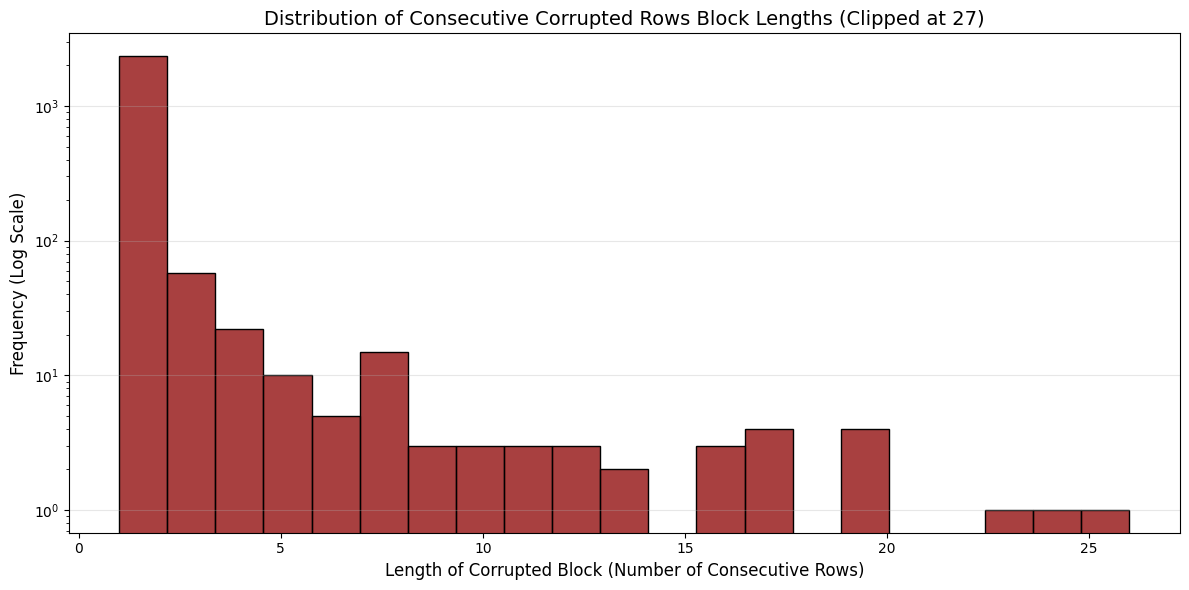

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.dataset as ds
from pathlib import Path

# Use the notebook-friendly version of tqdm
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

all_corrupt_lengths = []

directory = r"d:\MASTER THESIS DATA\bitmex\processed_5m_bidask"
data_path = Path(directory)
if data_path.exists():
    directories = [d for d in data_path.iterdir() if d.is_dir()]

    for symbol_dir in tqdm(directories, desc="Analyzing consecutive corrupted rows"):
        symbol = symbol_dir.name
        try:
            dataset = ds.dataset(symbol_dir, format="parquet")
            df = dataset.to_table().to_pandas()
        except:
            continue
            
        if df.empty:
            continue
            
        df = df.sort_values('timestamp')
        
        # 1. Identify corrupted rows using your existing logic
        null_prices = df[['mid_price', 'bid_price', 'ask_price']].isnull().any(axis=1)
        invalid_flag = ~df['is_valid'].astype(bool) if 'is_valid' in df.columns else pd.Series(False, index=df.index)
        zero_prices = (df[['mid_price', 'bid_price', 'ask_price']] <= 0.0).any(axis=1)
        
        mask = null_prices | invalid_flag | zero_prices
        
        # 2. Calculate lengths of consecutive True blocks in the mask
        is_corrupt = mask
        # ne(shift()) identifies boundaries where the condition changes True/False
        # cumsum() gives a unique ID to each contiguous block of identical values
        blocks = is_corrupt.ne(is_corrupt.shift()).cumsum()
        
        # Group by these blocks and sum the True values to get the length of each corrupt block
        block_lengths = is_corrupt.groupby(blocks).sum()
        
        # Keep only the blocks that represent corrupted data (where length > 0)
        corrupt_lengths = block_lengths[block_lengths > 0]
        
        if len(corrupt_lengths) > 0:
            all_corrupt_lengths.append(corrupt_lengths)

if all_corrupt_lengths:
    all_lengths_series = pd.concat(all_corrupt_lengths, ignore_index=True)
    
    print("="*60)
    print("DISTRIBUTION OF CONSECUTIVE CORRUPTED ROW LENGTHS")
    print("="*60)
    print("Top 15 most frequent lengths of corrupted data blocks (Num Rows : Frequency):")
    print(all_lengths_series.value_counts().sort_index().head(15))
    
    print("\nSummary Statistics of Block Lengths:")
    print(all_lengths_series.describe())
    
    # --- Visualization ---
    plt.figure(figsize=(12, 6))
    
    # Clip at 99th percentile to avoid a single extreme outlier stretching the plot too far
    clip_val = all_lengths_series.quantile(0.99)
    if pd.isna(clip_val) or clip_val <= 1:
        clip_val = all_lengths_series.max()
        
    plot_data = all_lengths_series[all_lengths_series <= clip_val]
    
    # Calculate appropriate bins
    bins = min(50, int(plot_data.nunique())) if plot_data.nunique() > 0 else 10
    
    sns.histplot(plot_data, bins=bins, kde=False, color='darkred')
    plt.title(f'Distribution of Consecutive Corrupted Rows Block Lengths (Clipped at {clip_val:.0f})', fontsize=14)
    plt.xlabel('Length of Corrupted Block (Number of Consecutive Rows)', fontsize=12)
    plt.ylabel('Frequency (Log Scale)', fontsize=12)
    plt.yscale('log')  # Log scale makes sense here, since length=1 is usually dominant
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No corrupted rows found.")
